In [ ]:
# Core imports
import os
import numpy as np
import pandas as pd

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, confusion_matrix, roc_auc_score, roc_curve

# Clustering
from sklearn.cluster import KMeans

# Plotting
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Create an artifacts folder for outputs
os.makedirs("artifacts", exist_ok=True)
print("Ready. Artifacts will be saved to:", os.path.abspath("artifacts"))


Ready. Artifacts will be saved to: /content/artifacts


## Part 1: Predict house prices based on square footage and location (Linear Regression)

### Dataset
We use the Ames Housing dataset and transform it to match the assignment schema:
- `price` from `SalePrice`
- `square_footage` from `GrLivArea`
- `location` from a bucketed version of `Neighborhood`

we map neighborhoods into three buckets using neighborhood median prices:
- Top third (highest median prices): Downtown
- Middle third: Suburb
- Bottom third: Rural




In [ ]:
# Data source:
# Ames Housing Dataset
AMES_PATH = "AmesHousing.csv"
df_ames = pd.read_csv(AMES_PATH)

# Inspect columns to find best matches for price, sqft, and neighborhood
# Standard Ames names are often SalePrice or Sale Price, Gr Liv Area or GrLivArea
col_map = {}
for target, options in {
    "price": ["Sale Price", "SalePrice"],
    "square_footage": ["Gr Liv Area", "GrLivArea"],
    "neighborhood": ["Neighborhood"]
}.items():
    for opt in options:
        if opt in df_ames.columns:
            col_map[opt] = target
            break

df = df_ames.rename(columns=col_map)[["price", "square_footage", "neighborhood"]].dropna()

# Bucket neighborhoods into Downtown/Suburb/Rural using neighborhood median price
neigh_median = df.groupby("neighborhood")["price"].median().sort_values()
n = len(neigh_median)

# Split into thirds
bottom = set(neigh_median.iloc[: n//3].index)
middle = set(neigh_median.iloc[n//3 : 2*n//3].index)
top = set(neigh_median.iloc[2*n//3 :].index)

def bucket_location(neigh: str) -> str:
    if neigh in top:
        return "Downtown"
    if neigh in middle:
        return "Suburb"
    return "Rural"

df["location"] = df["neighborhood"].map(bucket_location)
df = df.drop(columns=["neighborhood"])

print("Rows:", len(df))
print(df.head())
print("\nLocation distribution:")
print(df["location"].value_counts())

Rows: 2930
    price  square_footage location
0  215000            1656   Suburb
1  105000             896   Suburb
2  172000            1329   Suburb
3  244000            2110   Suburb
4  189900            1629   Suburb

Location distribution:
location
Suburb      1074
Downtown     946
Rural        910
Name: count, dtype: int64


In [ ]:
# Features and target
X = df[["square_footage", "location"]]
y = df["price"].values

# Preprocessing: OneHotEncoder for location, passthrough for square_footage
preprocessor = ColumnTransformer(
    transformers=[
        ("location", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["location"])
    ],
    remainder="passthrough"
)

# Model: Linear Regression (plus RidgeCV as a robustness check)
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RidgeCV(alphas=np.logspace(-2, 4, 30), cv=5))
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Fit and evaluate
lr_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)

def eval_reg(model, name: str):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    r2_tr = r2_score(y_train, pred_train)
    r2_te = r2_score(y_test, pred_test)
    # Fix: Removed 'squared=False' which is deprecated/removed in newer sklearn versions
    rmse_tr = np.sqrt(mean_squared_error(y_train, pred_train))
    rmse_te = np.sqrt(mean_squared_error(y_test, pred_test))
    print(f"{name}: R2 train={r2_tr:.4f}, test={r2_te:.4f}")
    print(f"{name}: RMSE train=${rmse_tr:,.0f}, test=${rmse_te:,.0f}")
    return r2_te

r2_lr = eval_reg(lr_model, "LinearRegression")
r2_ridge = eval_reg(ridge_model, "RidgeCV")

model = ridge_model if r2_ridge >= r2_lr else lr_model
print("\nSelected model:", "RidgeCV" if model is ridge_model else "LinearRegression")

# Predict the price for a 2000 sq ft house in Downtown
new_house = pd.DataFrame({"square_footage": [2000], "location": ["Downtown"]})
predicted_price = model.predict(new_house)[0]
print(f"\nPredicted price for a 2000 sq ft house in Downtown: ${predicted_price:,.2f}")

# Print model coefficients
ohe = model.named_steps["preprocessor"].named_transformers_["location"]
location_feature_names = ohe.get_feature_names_out(["location"]).tolist()
feature_names = location_feature_names + ["square_footage"]

coefficients = model.named_steps["regressor"].coef_

print("\nModel coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"  {feature}: {coef:,.2f}")

# Save test predictions
test_out = X_test.copy()
test_out["actual_price"] = y_test
test_out["predicted_price"] = model.predict(X_test)
test_out.to_csv("artifacts/part1_house_price_test_predictions.csv", index=False)
print("\nSaved: artifacts/part1_house_price_test_predictions.csv")

LinearRegression: R2 train=0.6645, test=0.6880
LinearRegression: RMSE train=$44,665, test=$50,013
RidgeCV: R2 train=0.6645, test=0.6880
RidgeCV: RMSE train=$44,665, test=$50,013

Selected model: LinearRegression

Predicted price for a 2000 sq ft house in Downtown: $268,264.99

Model coefficients:
  location_Downtown: 46,540.68
  location_Rural: -39,045.25
  location_Suburb: -7,495.43
  square_footage: 84.79

Saved: artifacts/part1_house_price_test_predictions.csv


### Interpretation

- The **square_footage** coefficient estimates how much the predicted price changes for each additional square foot, holding location constant.
- The **location** coefficients capture the average price shift associated with each location bucket (Downtown, Suburb, Rural), holding square footage constant.


## Part 2: Predict customer churn (Logistic Regression)

We use the Telco Customer Churn dataset. The model outputs a churn probability for each customer.
If the probability is greater than or equal to 0.5, we classify the customer as likely to churn.


Confusion matrix (rows=true, cols=pred):
 [[913 120]
 [174 200]]
ROC AUC: 0.8368
Saved: artifacts/part2_churn_predictions.csv


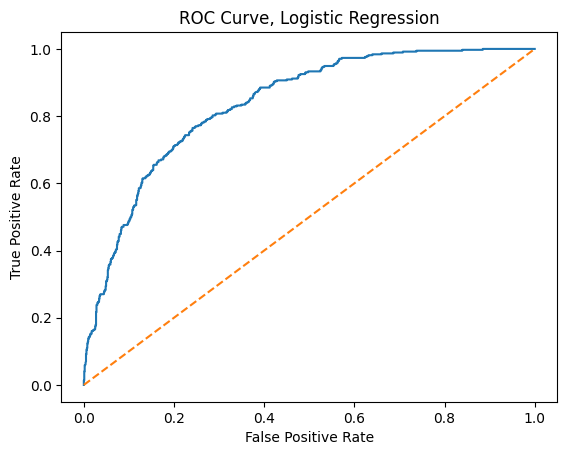

In [ ]:
# Data source:
# Telco Customer Churn dataset (IBM sample, widely distributed on Kaggle)
# Common Kaggle distribution: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

TELCO_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
telco = pd.read_csv(TELCO_PATH)

# Basic cleaning
# TotalCharges sometimes has blanks; coerce to numeric
telco["TotalCharges"] = pd.to_numeric(telco["TotalCharges"], errors="coerce")

# Drop rows with missing target or key numeric
telco = telco.dropna(subset=["Churn", "TotalCharges", "MonthlyCharges", "tenure"]).reset_index(drop=True)

# Target: Churn Yes/No to 1/0
y = (telco["Churn"].str.strip().str.lower() == "yes").astype(int).values

# Select a reasonable feature set
feature_cols_num = ["tenure", "MonthlyCharges", "TotalCharges"]
feature_cols_cat = [
    "Contract", "PaymentMethod", "InternetService",
    "OnlineSecurity", "TechSupport", "PaperlessBilling"
]

X = telco[feature_cols_num + feature_cols_cat].copy()

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), feature_cols_num),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), feature_cols_cat),
    ]
)

logreg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Fit
logreg.fit(X_train, y_train)

# Predict probabilities and class labels using threshold 0.5
proba = logreg.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

# Metrics
cm = confusion_matrix(y_test, pred)
auc = roc_auc_score(y_test, proba)

print("Confusion matrix (rows=true, cols=pred):\n", cm)
print(f"ROC AUC: {auc:.4f}")

# Save predictions
out = X_test.copy()
out["churn_actual"] = y_test
out["churn_probability"] = proba
out["churn_predicted_0_5"] = pred
out.to_csv("artifacts/part2_churn_predictions.csv", index=False)
print("Saved: artifacts/part2_churn_predictions.csv")

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, proba)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve, Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


### Interpretation
- The model outputs a **churn probability** such as 0.70, meaning an estimated 70 percent chance the customer churns.
- Using a **0.5 threshold**: probabilities at or above 0.5 are classified as "at risk".
- Business use: prioritize retention actions (discounts, outreach, service fixes) for high probability customers.


## Part 3: Customer Segmentation (K-Means)

We segment customers into groups using scaled numerical behavior features.
Steps:
1. Scale features
2. Use an elbow plot to choose K
3. Fit K-Means
4. Analyze cluster averages and propose marketing strategies


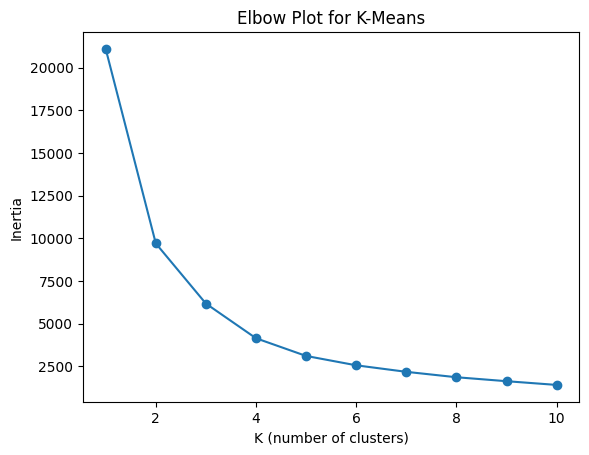

Cluster average characteristics:

            tenure  MonthlyCharges  TotalCharges
cluster                                         
0        10.277123       31.777771    303.821875
1        59.530987       93.306224   5548.653887
2        53.585850       34.920147   1836.581320
3        15.445227       80.791201   1252.816564

Saved: artifacts/part3_customer_clusters.csv


In [ ]:
# Prepare a segmentation dataset from Telco
seg = telco.copy()

# Use a compact numeric feature set that is easy to interpret
seg_features = ["tenure", "MonthlyCharges", "TotalCharges"]
X_seg = seg[seg_features].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_seg)

# Elbow method
inertias = []
k_values = range(1, 11)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow Plot for K-Means")
plt.xlabel("K (number of clusters)")
plt.ylabel("Inertia")
plt.show()

# Choose K (you can justify this choice from the elbow)
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

seg_out = X_seg.copy()
seg_out["cluster"] = clusters

# Cluster summary
cluster_summary = seg_out.groupby("cluster")[seg_features].mean().sort_index()
print("Cluster average characteristics:\n")
print(cluster_summary)

# Save cluster assignments
seg_out.to_csv("artifacts/part3_customer_clusters.csv", index=False)
print("\nSaved: artifacts/part3_customer_clusters.csv")


### Cluster analysis and marketing strategies (example)
Use the cluster averages printed above to label clusters. Typical patterns:

- High MonthlyCharges + low tenure: onboarding and retention offers, contract incentives.
- High tenure + moderate charges: loyalty rewards, upgrades, referral programs.
- Low charges + low tenure: low cost nurture campaigns, self service support.
- High TotalCharges: premium customers, exclusive promotions and priority support.

Update the text to match the cluster averages you observe after running the notebook.


## Part 4 (Extra Credit): Housing demand forecasting tool (Synthetic)

Goal:
- Create a CSV with historical monthly demand
- Load it using pandas
- Train a basic regression model
- Forecast next 6 months
- Visualize results
- Document assumptions and improvements


Saved synthetic demand history to: artifacts/part4_housing_demand_history.csv
Saved forecast to: artifacts/part4_housing_demand_forecast_next_6_months.csv


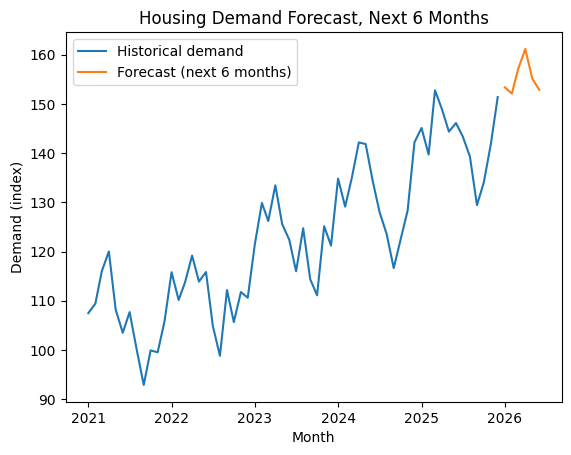

In [ ]:
# Generate a realistic synthetic monthly housing demand series (5 years)
dates = pd.date_range(start="2021-01-01", periods=60, freq="MS")

# Components: trend + seasonality + noise
t = np.arange(len(dates))
trend = 100 + 0.8 * t
seasonality = 10 * np.sin(2 * np.pi * t / 12) + 5 * np.cos(2 * np.pi * t / 12)
noise = np.random.normal(0, 5, size=len(dates))

demand = trend + seasonality + noise
demand = np.maximum(demand, 0)

demand_df = pd.DataFrame({
    "month": dates,
    "demand": demand
})

# Save to CSV to satisfy "reads historical data from a CSV file"
demand_csv_path = "artifacts/part4_housing_demand_history.csv"
demand_df.to_csv(demand_csv_path, index=False)
print("Saved synthetic demand history to:", demand_csv_path)

# Load and preprocess
hist = pd.read_csv(demand_csv_path, parse_dates=["month"]).sort_values("month")
hist["t"] = np.arange(len(hist))

# Add month as a categorical seasonality feature
hist["month_num"] = hist["month"].dt.month.astype(int)

X = hist[["t", "month_num"]]
y = hist["demand"].values

preprocessor = ColumnTransformer(
    transformers=[
        ("month_ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["month_num"])
    ],
    remainder="passthrough"
)

reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

reg.fit(X, y)

# Forecast next 6 months
future_dates = pd.date_range(start=hist["month"].max() + pd.offsets.MonthBegin(1), periods=6, freq="MS")
future = pd.DataFrame({
    "t": np.arange(len(hist), len(hist) + 6),
    "month_num": future_dates.month.astype(int)
})
future_pred = reg.predict(future)

forecast_df = pd.DataFrame({
    "month": future_dates,
    "forecast_demand": future_pred
})

# Save forecast
forecast_path = "artifacts/part4_housing_demand_forecast_next_6_months.csv"
forecast_df.to_csv(forecast_path, index=False)
print("Saved forecast to:", forecast_path)

# Visualize
plt.figure()
plt.plot(hist["month"], hist["demand"], label="Historical demand")
plt.plot(forecast_df["month"], forecast_df["forecast_demand"], label="Forecast (next 6 months)")
plt.title("Housing Demand Forecast, Next 6 Months")
plt.xlabel("Month")
plt.ylabel("Demand (index)")
plt.legend()
plt.show()


### Assumptions, challenges, and improvements
Assumptions:
- Demand has a stable linear trend plus yearly seasonality.
- No external shocks are modeled (interest rates, policy, supply constraints).

Challenges:
- Real demand data can have missing months, reporting changes, and outliers.
- A simple linear model may underfit if demand patterns are nonlinear.

Potential improvements:
- Use more features (inventory, mortgage rates, regional indicators).
- Try time series models (ARIMA, Prophet) or tree based regressors.
- Add backtesting and prediction intervals.
